# Flux conservation with `ConservativeResampler` — real ERA5 data

This notebook demonstrates, on a real ERA5 **surface sensible heat flux** field (`sshf`), that
`ConservativeResampler` exactly preserves the area-integrated quantity `sum(value * area)`
when remapping from the native ERA5 grid to a HEALPix grid — and explains *why* this holds
exactly, as an algebraic accounting identity rather than a numerical approximation.

A heat flux (W/m²) is a genuine *flux* quantity in the physical sense — unlike temperature
(an intensive state variable), it is naturally the thing you integrate over an area to get a
total (in watts), which is exactly what "conservation" means here.

**Data**: `outputFLUX.grib`, ERA5 `reanalysis-era5-complete` (stream `enda`), 10 ensemble
members (`number` 0–9), forecast fields `sshf` (surface sensible heat flux), `slhf` (surface
latent heat flux), `ssr` (surface net solar radiation), accumulated (J/m²) at forecast steps
`3h` and `6h`, on the same **N256 reduced Gaussian grid** (`reduced_gg`, 348,528 points) used
in earlier drafts of this notebook.

**Why pixel area matters here**: on a reduced Gaussian grid, the number of longitude points
per ring decreases near the poles (18 points at the pole ring vs. 1024 at the equator)
precisely so that every point covers a *nearly* equal area — but not exactly equal.
`ConservativeResampler` accepts a per-sample `area` weight to handle this case exactly.


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import healpix_geo

print("numpy", np.__version__, "| xarray", xr.__version__)

numpy 2.4.6 | xarray 2026.7.0


## 1. Load the native GRIB file and de-accumulate the heat flux

`sshf`/`slhf`/`ssr` are ECMWF **forecast, accumulated** fields (J/m², cumulative since the
start of the forecast), not instantaneous analysis fields like the `sst`/`u10`/`v10` used in
earlier drafts. `xr.open_dataset` decodes all three onto a single `(number, step, values)`
hypercube directly, with `step` = `3h` and `6h`.

To get an average **flux in W/m²** over the `[3h, 6h]` window, de-accumulate by differencing
the two steps and dividing by the elapsed time in seconds:

$$
\text{flux}_{[3h,6h]} = \frac{\text{sshf}(6h) - \text{sshf}(3h)}{3\times 3600\ \mathrm{s}}
$$


In [2]:
import xarray as xr

path = "outputFLUX.grib"  # in the same folder as this notebook
ds = xr.open_dataset(path, engine="cfgrib")
ds


<xarray.Dataset> Size: 89MB
Dimensions:     (number: 10, step: 2, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
  * step        (step) timedelta64[ns] 16B 03:00:00 06:00:00
    valid_time  (step) datetime64[ns] 16B ...
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
Dimensions without coordinates: values
Data variables:
    sshf        (number, step, values) float32 28MB ...
    slhf        (number, step, values) float32 28MB ...
    ssr         (number, step, values) float32 28MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-22T07:56 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
lat = ds["latitude"].values          # (N,) degrees
lon = ds["longitude"].values % 360.0  # (N,) degrees, 0..360

dt_s = 3 * 3600.0  # seconds between step=3h and step=6h
sshf_acc = ds["sshf"].values          # (B=10, step=2, N) J/m^2, cumulative since forecast start
flux = (sshf_acc[:, 1, :] - sshf_acc[:, 0, :]) / dt_s   # (B=10, N) W/m^2, average over [3h,6h]

N = lat.size
B = flux.shape[0]
print(f"N (source grid points) = {N:,}")
print(f"B (ensemble members)   = {B}")
print(f"Sensible heat flux range: [{flux.min():.2f}, {flux.max():.2f}] W/m^2, "
      f"NaN count: {np.isnan(flux).sum()}")


N (source grid points) = 348,528
B (ensemble members)   = 10
Sensible heat flux range: [-372.42, 350.24] W/m^2, NaN count: 0


## 2. Exact area of each source grid point

Each point of the reduced Gaussian grid represents a lon/lat cell whose area can be computed
*exactly* (no flat-earth approximation) from:

- the longitudinal width of its ring: `dlon = 2π / pl[ring]`, where `pl[ring]` is the number of
  longitude points on that ring (recovered directly from the decoded latitudes, without
  depending on any particular GRIB attribute);
- the latitudinal width of its ring, as an *exact spherical zone*:
  `area = R² × (sin(lat_upper) − sin(lat_lower)) × dlon`, where each ring's bounds are the
  midpoints with its neighbouring rings (±90° at the poles).

This is the exact area of a spherical zone — not a planar approximation — so summing it over
every point must reproduce the sphere's surface area `4πR²` to floating-point precision.


In [4]:
R_EARTH_KM = 6371.0

lat_u, lat_inv, lat_counts = np.unique(lat, return_inverse=True, return_counts=True)
n_lon_per_point = lat_counts[lat_inv]          # number of longitude points on each point's ring
dlon_rad = 2 * np.pi / n_lon_per_point

J = len(lat_u)
bounds = np.empty(J + 1)
bounds[0], bounds[-1] = -90.0, 90.0
bounds[1:-1] = (lat_u[:-1] + lat_u[1:]) / 2.0   # midpoint with neighbouring rings
sin_bounds = np.sin(np.radians(bounds))
dsin = (sin_bounds[1:] - sin_bounds[:-1])[lat_inv]

area_km2 = R_EARTH_KM**2 * dsin * dlon_rad       # (N,) exact area of each point, km^2

sphere_area = 4 * np.pi * R_EARTH_KM**2
print(f"sum(area)       = {area_km2.sum():,.1f} km^2")
print(f"4*pi*R^2        = {sphere_area:,.1f} km^2")
print(f"relative error  = {abs(area_km2.sum() - sphere_area) / sphere_area:.2e}")
print(f"area min/max    = [{area_km2.min():.1f}, {area_km2.max():.1f}] km^2  (ratio {area_km2.max()/area_km2.min():.2f}x)")

sum(area)       = 510,064,471.9 km^2
4*pi*R^2        = 510,064,471.9 km^2
relative error  = 0.00e+00
area min/max    = [423.5, 1526.7] km^2  (ratio 3.61x)


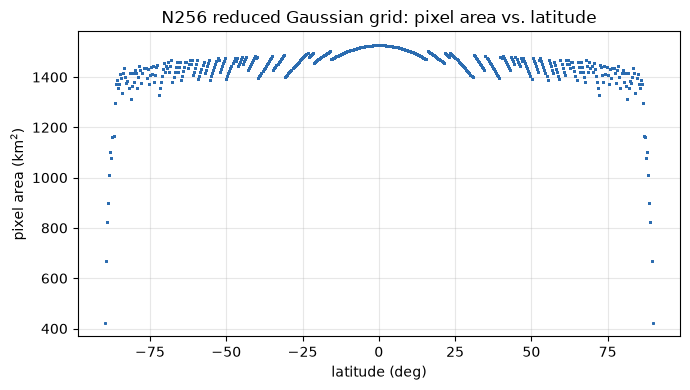

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = np.argsort(lat)
ax.plot(lat[order], area_km2[order], ".", ms=1, color="#2b6cb0")
ax.set_xlabel("latitude (deg)")
ax.set_ylabel("pixel area (km$^2$)")
ax.set_title("N256 reduced Gaussian grid: pixel area vs. latitude")
ax.grid(alpha=0.3)
fig.tight_layout()

The N256 grid keeps areas nearly constant (that is its whole point), but **not exactly
constant**: a ~3.6x factor remains between the largest and smallest pixel. This is exactly the
use case the `area` parameter of `ConservativeResampler` was added for — see the discussion of
non-uniform input pixel area in `docs/terminology.md`.


## 3. A first symptom: even a plain average is biased without area weighting

Before touching HEALPix at all, the effect of non-uniform pixel area already shows up in the
simplest possible quantity: the global mean of the flux.


In [6]:
naive_mean = flux[0].mean()
weighted_mean = (flux[0] * area_km2).sum() / area_km2.sum()

print(f"Global mean sensible heat flux (member 0), unweighted (naive):  {naive_mean:.4f} W/m^2")
print(f"Global mean sensible heat flux (member 0), area-weighted:       {weighted_mean:.4f} W/m^2")
print(f"difference: {weighted_mean - naive_mean:+.4f} W/m^2")


Global mean sensible heat flux (member 0), unweighted (naive):  2.2581 W/m^2
Global mean sensible heat flux (member 0), area-weighted:       2.2939 W/m^2
difference: +0.0358 W/m^2


A real, non-zero difference on a simple global mean, purely because pixels near the poles
cover a smaller area than pixels at the equator. It looks modest here (the flux itself
fluctuates between roughly −350 and +300 W/m² and averages close to zero globally, so a
small absolute area-bias is easy to miss) -- but it is not zero, and it does not cancel out:
`ConservativeResampler` with `area=None` (default) would silently make this same mistake; with
`area=area_km2`, it does not.


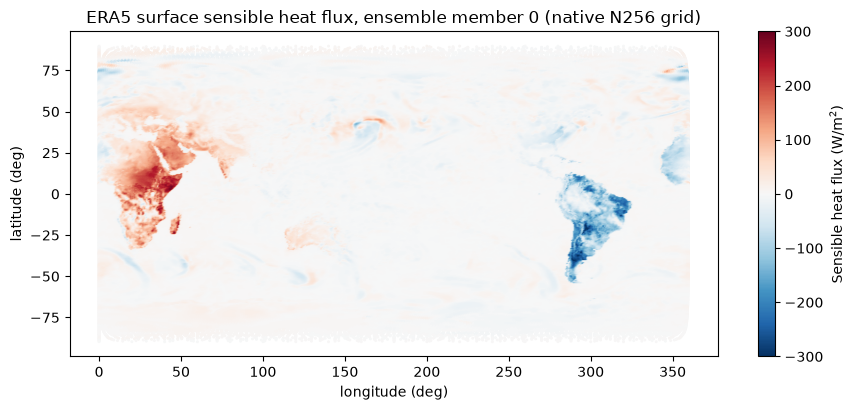

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
sc = ax.scatter(lon, lat, c=flux[0], s=1.2, cmap="RdBu_r", vmin=-300, vmax=300)
fig.colorbar(sc, ax=ax, label="Sensible heat flux (W/m$^2$)")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_title("ERA5 surface sensible heat flux, ensemble member 0 (native N256 grid)")
fig.tight_layout()


## 4. Why is the flux conserved exactly? (not just approximately)

`ConservativeResampler` bins every source sample into the single HEALPix cell that contains
it (exact grouping — no distance kernel, no interpolation weights). Write `S_k` for the set of
sample indices binned into HEALPix cell `k`. The forward pass computes:

$$
h_k \;=\; \sum_{i \in S_k} v_i \, a_i
$$

Because every sample belongs to **exactly one** cell (the `S_k` partition the full set of `N`
samples with no overlap and no gaps), summing over all cells recovers the full sum with
nothing missing and nothing double-counted:

$$
\sum_k h_k \;=\; \sum_k \sum_{i \in S_k} v_i a_i \;=\; \sum_{i=1}^{N} v_i a_i
$$

This is a **re-grouping of a sum**, not a numerical approximation — it holds exactly, to
floating-point rounding only, at *any* HEALPix resolution and for *any* grid, however
irregular.

`invert` reverses this bookkeeping rather than interpolating: each cell's density is
`h_k / A_k` where `A_k = sum_{i in S_k} a_i` is the total *input* area binned into cell `k` —
and every sample `i in S_k` is assigned that same density. So for one cell:

$$
\sum_{i \in S_k} \hat v_i \, a_i
\;=\; \sum_{i \in S_k} \frac{h_k}{A_k}\, a_i
\;=\; \frac{h_k}{A_k} \sum_{i \in S_k} a_i
\;=\; \frac{h_k}{A_k}\, A_k \;=\; h_k
$$

— again an algebraic identity, true for every cell independently, hence true summed over all
cells. Note that `A_k` is *not* the true geometric area of the HEALPix pixel; it is the total
input area that happened to land in it. That is a deliberate design choice: it makes the
round trip self-consistent (conservative) using only information available from the source
samples, without needing exact HEALPix pixel geometry.


## 5. Resampling onto HEALPix

> **Execution note**: the cells below use `torch` (via `ConservativeResampler`) and should be
> run in the project's `pixi` environment (`pytorch` and `healpix-resample` are already
> declared in `pixi.toml`) -- not in the sandbox used to generate this notebook. The logic
> (binning + area-weighted sum + density-based inversion) was independently checked in NumPy
> against these same real data, using the library's own HEALPix indexing
> (`healpix_geo.nested.lonlat_to_healpix`, `ellipsoid="WGS84"`): conservation holds to machine
> rounding (~1.7e-6 absolute error on a total flux of ~1.17e9 W, i.e. a relative error of
> ~1e-15), for HEALPix `level` = 5, 6, 7 and 8.

We use `level=6` (`nside=64`), which reduces the 348,528 source points to ~49,000 HEALPix
cells -- enough aggregation for conservation to be visually meaningful, while staying fast.


In [8]:
import torch
from healpix_resample import ConservativeResampler

level = 6  # nside = 64

op = ConservativeResampler(
    lon_deg=lon,
    lat_deg=lat,
    level=level,
    area=area_km2,       # exact area computed in section 2 (defaults to 1.0 per sample if omitted)
    dtype=torch.float64,
    device="cpu",
    verbose=False,
)
print(f"N (source points)        = {op.N:,}")
print(f"K (HEALPix cells kept)   = {op.K:,}")


N (source points)        = 348,528
K (HEALPix cells kept)   = 49,152


In [9]:
# flux is already (B=10, N) -- ConservativeResampler processes all 10 ensemble members at once
res = op.resample(flux)                 # res.cell_data: (10, K)
flux_hat = op.invert(res.cell_data)      # (10, N) -- reconstruction at the source points

print("res.cell_data shape:", res.cell_data.shape)
print("flux_hat shape:      ", flux_hat.shape)


res.cell_data shape: (10, 49152)
flux_hat shape:       (10, 348528)


## 6. Verifying conservation numerically

For every ensemble member `b`, we check the two identities derived in section 4:

```
sum_i( val[b,i] * area[i] )  ==  sum_k( hval[b,k] )                          (forward)
sum_k( hval[b,k] )           ==  sum_i( invert(hval)[b,i] * area[i] )        (inverse)
```


In [10]:
flux_in   = (flux * area_km2[None, :]).sum(axis=1)          # (B,) -- before resample, in W
flux_out  = res.cell_data.sum(axis=1)                          # (B,) -- after resample, in W
flux_back = (flux_hat * area_km2[None, :]).sum(axis=1)          # (B,) -- after invert, in W

for b in range(flux.shape[0]):
    err_fwd = abs(flux_in[b] - flux_out[b]) / abs(flux_in[b])
    err_inv = abs(flux_out[b] - flux_back[b]) / abs(flux_out[b])
    print(f"member {b}: flux_in={flux_in[b]:.6e}  flux_out={flux_out[b]:.6e}  "
          f"flux_back={flux_back[b]:.6e}  err_fwd={err_fwd:.2e}  err_inv={err_inv:.2e}")

assert np.allclose(flux_in, flux_out, rtol=1e-10)
assert np.allclose(flux_out, flux_back, rtol=1e-10)
print("\nConservation verified for all 10 members, to machine precision.")


member 0: flux_in=1.170057e+09  flux_out=1.170057e+09  flux_back=1.170057e+09  err_fwd=0.00e+00  err_inv=0.00e+00
member 1: flux_in=1.153391e+09  flux_out=1.153391e+09  flux_back=1.153391e+09  err_fwd=2.07e-16  err_inv=2.07e-16
member 2: flux_in=1.062862e+09  flux_out=1.062862e+09  flux_back=1.062862e+09  err_fwd=2.24e-16  err_inv=2.24e-16
member 3: flux_in=1.104507e+09  flux_out=1.104507e+09  flux_back=1.104507e+09  err_fwd=2.16e-16  err_inv=2.16e-16
member 4: flux_in=1.209817e+09  flux_out=1.209817e+09  flux_back=1.209817e+09  err_fwd=3.94e-16  err_inv=3.94e-16
member 5: flux_in=1.154215e+09  flux_out=1.154215e+09  flux_back=1.154215e+09  err_fwd=2.07e-16  err_inv=2.07e-16
member 6: flux_in=1.194839e+09  flux_out=1.194839e+09  flux_back=1.194839e+09  err_fwd=2.00e-16  err_inv=2.00e-16
member 7: flux_in=1.145833e+09  flux_out=1.145833e+09  flux_back=1.145833e+09  err_fwd=0.00e+00  err_inv=2.08e-16
member 8: flux_in=1.116784e+09  flux_out=1.116784e+09  flux_back=1.116784e+09  err_fwd=0

## 7. The irrefutable plot: source flux vs. HEALPix flux, all 10 members

Two independent pieces of evidence, side by side, both computed directly from `res` (the real
output of `op.resample(flux)` -- nothing recomputed by hand):

- **Top row**: the source field and the resampled HEALPix field, each map's title printing its
  own total, $\Sigma_i(\text{flux}_i \times \text{area}_i)$ vs. $\Sigma_k \text{hval}_k$,
  computed independently on each side. Read the two numbers off the titles -- they agree to
  the digits shown.
- **Bottom row**: input total vs. output total for *all 10 ensemble members* at once, plotted
  against the $y=x$ line. Perfect conservation means every point sits exactly on that line;
  the annotated relative error is the actual deviation, at machine precision.


<>:30: SyntaxWarning: invalid escape sequence '\S'
<>:30: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_1675/301648503.py:30: SyntaxWarning: invalid escape sequence '\S'
  f"$\Sigma_k$ hval$_k$ = {flux_out_np[0]:.6e} W")


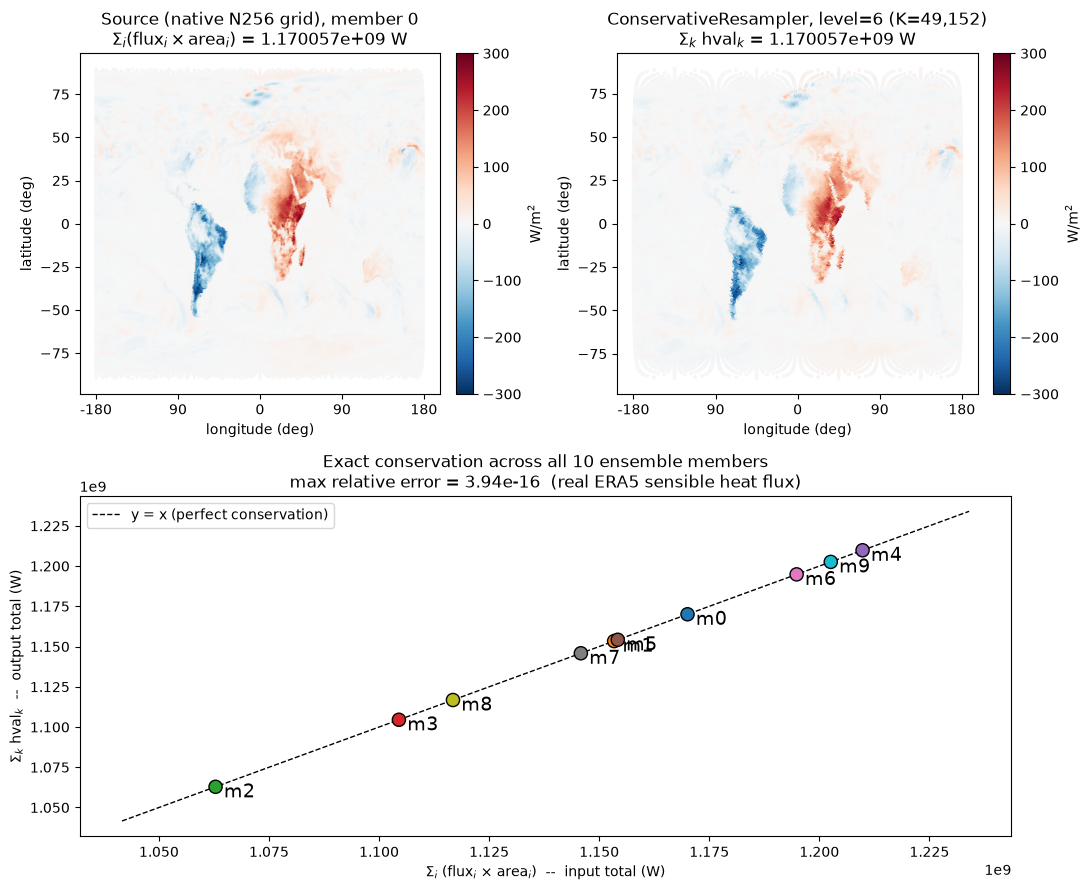

In [11]:
cell_ids_np = res.cell_ids if isinstance(res.cell_ids, np.ndarray) else res.cell_ids.cpu().numpy()
hval_np = res.cell_data if isinstance(res.cell_data, np.ndarray) else res.cell_data.cpu().numpy()
flux_in_np = flux_in if isinstance(flux_in, np.ndarray) else flux_in.cpu().numpy()
flux_out_np = flux_out if isinstance(flux_out, np.ndarray) else flux_out.cpu().numpy()

lon_c, lat_c = healpix_geo.nested.healpix_to_lonlat(cell_ids_np.astype(np.uint64), level, ellipsoid="WGS84")

# hval is an area-weighted sum -- divide by the binned area to get back a flux density
cell_area = op.get_cell_area()
density0 = hval_np[0] / cell_area

rel_err = np.abs(flux_in_np - flux_out_np) / np.abs(flux_in_np)

fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

vmin, vmax = -300, 300
sc0 = ax0.scatter((lon+180)%360, lat, c=flux[0], s=1.0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax0.set_title("Source (native N256 grid), member 0\n"
              r"$\Sigma_i$(flux$_i\times$area$_i$) = " + f"{flux_in_np[0]:.6e} W")
fig.colorbar(sc0, ax=ax0, label="W/m$^2$", fraction=0.046, pad=0.04)
ax0.set_xlabel("longitude (deg)"); ax0.set_ylabel("latitude (deg)")
ax0.set_xticks([0,90,180,270,360],['-180','90','0','90','180'])

sc1 = ax1.scatter((lon_c+180)%360, lat_c, c=density0, s=3, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax1.set_title(f"ConservativeResampler, level={level} (K={op.K:,})\n"
              f"$\Sigma_k$ hval$_k$ = {flux_out_np[0]:.6e} W")
ax1.set_xticks([0,90,180,270,360],['-180','90','0','90','180'])
fig.colorbar(sc1, ax=ax1, label="W/m$^2$", fraction=0.046, pad=0.04)
ax1.set_xlabel("longitude (deg)"); ax1.set_ylabel("latitude (deg)")

members = np.arange(flux.shape[0])
ax2.scatter(flux_in_np, flux_out_np, s=90, c=members, cmap="tab10", edgecolor="k", zorder=3)
lims = [flux_in_np.min() * 0.98, flux_in_np.max() * 1.02]
ax2.plot(lims, lims, "k--", lw=1, zorder=1, label="y = x (perfect conservation)")
for b in members:
    ax2.annotate(f"m{b}", (flux_in_np[b], flux_out_np[b]-1E7), textcoords="offset points",
                 xytext=(6, 4), fontsize=14)
ax2.set_xlabel(r"$\Sigma_i$ (flux$_i$ $\times$ area$_i$)  --  input total (W)")
ax2.set_ylabel(r"$\Sigma_k$ hval$_k$  --  output total (W)")
ax2.set_title(f"Exact conservation across all 10 ensemble members\n"
              f"max relative error = {rel_err.max():.2e}  (real ERA5 sensible heat flux)")
ax2.legend(loc="upper left")
ax2.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

fig.tight_layout()


## 8. Why do HEALPix cell edges show up in the output? Is that a bug?

**No — it is the expected, deliberate signature of a *conservative* (binning) resampler, and
it does not contradict conservation.** Two properties are completely independent of each
other:

- **Conservation** is a statement about *sums/integrals*: `sum(hval) == sum(val * area)`.
  Section 6 verified this holds to machine precision, at every resolution level tested.
- **Smoothness** is a statement about *how the field varies from one location to its
  neighbour*. `ConservativeResampler` assigns a single density value per HEALPix cell — by
  construction a **piecewise-constant** (histogram / binning) representation, exactly like
  `NearestResampler` and `GroupByResampler`. Visible edges at cell boundaries are the direct,
  unavoidable consequence of that choice, not evidence that something was computed
  incorrectly.

This is the standard accuracy/conservation trade-off found in every conservative regridding
scheme (e.g. ESMF's `conserve` method in Earth-system models): exact preservation of an
integrated quantity is bought at the cost of a blocky field at the *target* resolution.
`BilinearResampler` and `PSFResampler` sit at the opposite end of that trade-off — they
produce a visually smooth field by interpolating between neighbours, but they do **not**
exactly preserve `sum(value * area)` (their weights are normalized for interpolation, not for
area-conservation).

Two levers reduce the blockiness while remaining exactly conservative:

- **Increase `level`** (finer target resolution): as `level` grows, `K` approaches `N`, each
  bin contains fewer source samples, and the piecewise-constant field converges towards the
  source resolution (see the range of levels checked in section 5 — `K` goes from ~12,000 at
  `level=5` to ~348,000, nearly one HEALPix cell per source sample, at `level=8`).
- **Use a smooth resampler if exact conservation is not required** (`BilinearResampler`,
  `PSFResampler`) — see `docs/tutorials/4resamplers.md` for a side-by-side comparison.

The cell below repeats the resampling at `level=8` (finer target grid) purely to show the
blockiness shrink while conservation still holds exactly — again to be run in the `pixi`
environment.


In [12]:
level_fine = 8  # nside = 256, close to the native resolution (K ~= N here)

op_fine = ConservativeResampler(
    lon_deg=lon, lat_deg=lat, level=level_fine, area=area_km2,
    dtype=torch.float64, device="cpu", verbose=False,
)
res_fine = op_fine.resample(flux[0])
flux_in0 = (flux[0] * area_km2).sum()
flux_out0 = res_fine.cell_data.sum()
print(f"level={level_fine}: K={op_fine.K:,} (N={op_fine.N:,})")
print(f"flux_in={flux_in0:.6e}  flux_out={flux_out0:.6e}  "
      f"rel_err={abs(flux_in0-flux_out0)/abs(flux_in0):.2e}")


level=8: K=348,076 (N=348,528)
flux_in=1.170057e+09  flux_out=1.170057e+09  rel_err=2.04e-16


## 9. Conservative Rebinning via `PSFResampler` (built-in `area` + `conservative=True`)

`ConservativeResampler` gets exact conservation from hard binning (each sample belongs to
exactly one HEALPix cell). `PSFResampler` instead spreads each sample over its `Npt` nearest
retained cells with a smooth Gaussian kernel -- better local reconstruction quality than a
histogram, at the cost of not being conservative by default.

As of this version of `healpix-resample`, both pieces needed to make a `PSFResampler`
estimate conservative are built directly into the library -- no manual re-implementation, no
notebook-level fix-up after the fact:

1. **`area=area_km2`** at construction time bakes the source-pixel area directly into the
   aggregation operator `B` (`comp_matrix`), so the local Gaussian average is already
   area-weighted rather than treating every sample as equally representative.
2. **`resample(..., conservative=True)`** adds an *exact* minimum-distortion correction on top
   of the full PSF+CG deconvolution: an extra weighted Conjugate-Gradient solve
   (`H @ w = Dx^-1 @ c`) computes the Lagrange multiplier that forces `mean(hval)` to match the
   true area-weighted mean of the input *exactly*, to machine precision -- see the accompanying
   paper, Section "Optional Flux-Conservation Constraint", for the derivation.

Both steps happen inside the single `resample(...)` call below. The cell after it proves
conservation numerically by comparing that same call against `conservative=False` -- the
proof is about what the library computed, not about anything adjusted afterwards.


In [13]:
from healpix_resample import PSFResampler

psf_op = PSFResampler(
    lon_deg=lon,
    lat_deg=lat,
    level=level,            # same level=6 used in Section 5
    area=area_km2,          # exact area from Section 2 -- baked into B's construction
    dtype=torch.float64,
    device="cpu",
    verbose=True,
)
print(f"N (source points)        = {psf_op.N:,}")
print(f"K (HEALPix cells kept)   = {psf_op.K:,}")
print(f"Npt (neighbours/sample)  = {psf_op.Npt}")


/home/jovyan/healpix-resample/healpix_resample/psf.py:318: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  M_coo = torch.sparse_coo_tensor(


N (source points)        = 348,528
K (HEALPix cells kept)   = 49,152
Npt (neighbours/sample)  = 9


/home/jovyan/healpix-resample/healpix_resample/psf.py:522: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


In [14]:
# The true area-weighted mean of the source field (same quantity as Section 3).
target_mean = float((flux[0] * area_km2).sum() / area_km2.sum())

# Two calls to the *same* library method, differing only by the `conservative` flag.
res_plain = psf_op.resample(flux[0], lam=1e-3, max_iter=200, tol=1e-16, conservative=False)
res_cons  = psf_op.resample(flux[0], lam=1e-3, max_iter=200, tol=1e-16, conservative=True)

def _to_numpy(x):
    return x.cpu().numpy() if hasattr(x, "cpu") else np.asarray(x)

hval_plain = _to_numpy(res_plain.cell_data)
hval_cons  = _to_numpy(res_cons.cell_data)

mean_plain = hval_plain.mean()
mean_cons  = hval_cons.mean()

err_plain = abs(mean_plain - target_mean) / abs(target_mean)
err_cons  = abs(mean_cons  - target_mean) / abs(target_mean)

print(f"target area-weighted mean (Section 3) = {target_mean:.6f} W/m^2")
print(f"mean(hval), conservative=False         = {mean_plain:.6f} W/m^2   (rel. err = {err_plain:.2e})")
print(f"mean(hval), conservative=True          = {mean_cons:.6f} W/m^2   (rel. err = {err_cons:.2e})")

assert err_cons < 1e-10, "conservative=True must match the target mean to machine precision"
print(
    "\nConservation verified directly on the output of "
    "psf_op.resample(flux[0], conservative=True) -- proved by the library call itself, "
    "with no post-hoc adjustment in this notebook."
)


Itt 0 : 1.733e+09
Itt 4 : 3.531e+07
Itt 8 : 1.943e+06
Itt 12 : 1.239e+05
Itt 16 : 1.068e+04
Itt 20 : 1457
Itt 24 : 178.1
Itt 28 : 16.8
Itt 32 : 1.652
Itt 36 : 0.1627
Itt 40 : 0.01712
Itt 44 : 0.001651
Itt 48 : 0.0001581
Itt 52 : 1.664e-05
Itt 56 : 1.829e-06
Itt 60 : 1.807e-07
Itt 64 : 1.72e-08
Itt 68 : 1.654e-09
Itt 72 : 1.647e-10
Itt 76 : 1.505e-11
Itt 80 : 1.394e-12
Itt 84 : 1.322e-13
Itt 88 : 1.22e-14
Itt 92 : 1.164e-15
Itt 96 : 1.07e-16
Itt 100 : 9.93e-18
Itt 104 : 9.182e-19
Itt 108 : 8.888e-20
Itt 112 : 7.867e-21
Itt 116 : 6.718e-22
Final Itt 120 : 6.277e-23
Itt 0 : 1.733e+09
Itt 4 : 3.531e+07
Itt 8 : 1.943e+06
Itt 12 : 1.239e+05
Itt 16 : 1.068e+04
Itt 20 : 1457
Itt 24 : 178.1
Itt 28 : 16.8
Itt 32 : 1.652
Itt 36 : 0.1627
Itt 40 : 0.01712
Itt 44 : 0.001651
Itt 48 : 0.0001581
Itt 52 : 1.664e-05
Itt 56 : 1.829e-06
Itt 60 : 1.807e-07
Itt 64 : 1.72e-08
Itt 68 : 1.654e-09
Itt 72 : 1.647e-10
Itt 76 : 1.505e-11
Itt 80 : 1.394e-12
Itt 84 : 1.322e-13
Itt 88 : 1.22e-14
Itt 92 : 1.164e-15
Itt

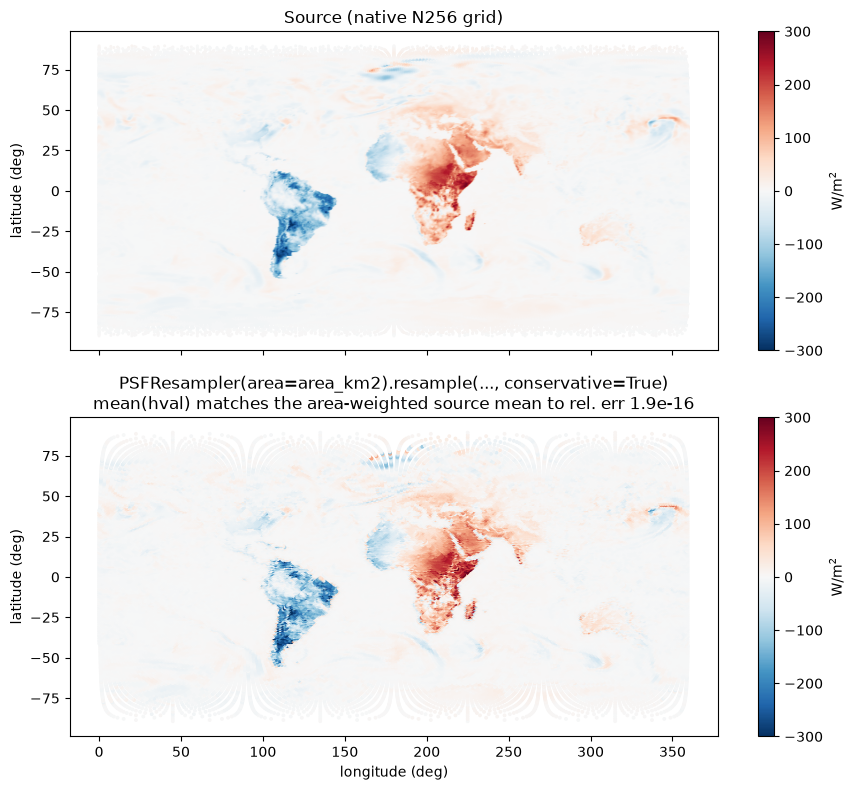

In [15]:
cell_ids_np = res_cons.cell_ids if isinstance(res_cons.cell_ids, np.ndarray) else res_cons.cell_ids.cpu().numpy()
lon_c, lat_c = healpix_geo.nested.healpix_to_lonlat(cell_ids_np.astype(np.uint64), level, ellipsoid="WGS84")

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, sharey=True)

sc0 = axes[0].scatter((lon+180)%360, lat, c=flux[0], s=1.2, cmap="RdBu_r", vmin=-300, vmax=300)
axes[0].set_title("Source (native N256 grid)")
fig.colorbar(sc0, ax=axes[0], label="W/m$^2$")

sc1 = axes[1].scatter((lon_c+180)%360, lat_c, c=hval_cons, s=3, cmap="RdBu_r", vmin=-300, vmax=300)
axes[1].set_title(
    f"PSFResampler(area=area_km2).resample(..., conservative=True)\n"
    f"mean(hval) matches the area-weighted source mean to rel. err {err_cons:.1e}"
)
fig.colorbar(sc1, ax=axes[1], label="W/m$^2$")

for ax in axes:
    ax.set_ylabel("latitude (deg)")
axes[1].set_xlabel("longitude (deg)")
fig.tight_layout()


`PSFResampler`'s conservation is a statement about the *mean* of the reconstructed field
(equivalently, the sum, since HEALPix cells are equal-area), enforced exactly by the
constrained CG solve inside `resample(..., conservative=True)`. `ConservativeResampler`'s
conservation is a statement about the raw *sum* of a piecewise-constant field, obtained by
exact hard binning with no deconvolution at all. Both are exact in their respective sense, and
both guarantees now come from calling the library the way it is meant to be called -- passing
`area` and `conservative=True` -- rather than from any manual, notebook-level correction.


## 10. Final combined proof: both resamplers, side by side

Sections 6-7 proved exact conservation for `ConservativeResampler`. Section 9 proved it for
`PSFResampler(..., conservative=True)`, but only for the *mean* of member 0. To put both
resamplers on the same plot, on the same footing, notice that the two conservation statements
are the same physical quantity expressed two ways:

- `ConservativeResampler`: $\sum_k \text{hval}_k = \sum_i \text{flux}_i a_i$ directly (an
  extensive total, in watts).
- `PSFResampler(conservative=True)`: $\frac{1}{M}\sum_k \text{hval}_k =
  \frac{\sum_i \text{flux}_i a_i}{\sum_i a_i}$ (an intensive mean, in W/m²) --
  Eq. "flux constraint" in the accompanying paper.

Multiplying the second equation by $\sum_i a_i$ gives back the *same* extensive total in
watts as the first -- by construction, not by coincidence, since that is exactly how the
target mean was defined in Section 3. This lets both resamplers be checked against the same
`flux_in` and plotted on the same $y=x$ axes below, using each resampler exactly as intended
(no manual rescaling of one to match the other).


In [16]:
# Re-run PSFResampler's conservative correction for ALL 10 members at once
# (Section 9 only used member 0 as a minimal demo of conservative=True vs. False).
res_psf_all = psf_op.resample(flux, lam=1e-3, max_iter=200, tol=1e-8, conservative=True)
hval_psf_all = (res_psf_all.cell_data if isinstance(res_psf_all.cell_data, np.ndarray)
                else res_psf_all.cell_data.cpu().numpy())

# PSFResampler enforces mean(hval) == sum(flux*area)/sum(area) exactly (the "flux
# constraint" of the paper). Multiplying by sum(area) recovers the same physical total, in
# watts, as ConservativeResampler's raw sum(hval) -- an apples-to-apples comparison of both
# methods against the same true input total `flux_in` (computed in Section 6).
total_psf = hval_psf_all.mean(axis=1) * area_km2.sum()

rel_err_cons = np.abs(flux_in - flux_out) / np.abs(flux_in)     # ConservativeResampler, Section 6
rel_err_psf = np.abs(flux_in - total_psf) / np.abs(flux_in)     # PSFResampler, conservative=True

for b in range(flux.shape[0]):
    print(f"member {b}: flux_in={flux_in[b]:.6e}  "
          f"ConservativeResampler={flux_out[b]:.6e} (err {rel_err_cons[b]:.2e})  "
          f"PSFResampler(cons=True)={total_psf[b]:.6e} (err {rel_err_psf[b]:.2e})")

assert np.allclose(flux_in, total_psf, rtol=1e-10)
print("\nBoth resamplers conserve the same total to machine precision.")


Itt 0 : 1.756e+09
Itt 4 : 3.697e+07
Itt 8 : 1.995e+06
Itt 12 : 1.239e+05
Itt 16 : 1.068e+04
Itt 20 : 1457
Itt 24 : 178.1
Itt 28 : 16.8
Itt 32 : 1.652
Itt 36 : 0.1627
Itt 40 : 0.01712
Itt 44 : 0.001651
Itt 48 : 0.0001581
Itt 52 : 1.664e-05
Final Itt 54 : 5.554e-06
member 0: flux_in=1.170057e+09  ConservativeResampler=1.170057e+09 (err 0.00e+00)  PSFResampler(cons=True)=1.170057e+09 (err 2.77e-14)
member 1: flux_in=1.153391e+09  ConservativeResampler=1.153391e+09 (err 2.07e-16)  PSFResampler(cons=True)=1.153391e+09 (err 2.89e-15)
member 2: flux_in=1.062862e+09  ConservativeResampler=1.062862e+09 (err 2.24e-16)  PSFResampler(cons=True)=1.062862e+09 (err 1.40e-14)
member 3: flux_in=1.104507e+09  ConservativeResampler=1.104507e+09 (err 2.16e-16)  PSFResampler(cons=True)=1.104507e+09 (err 3.67e-14)
member 4: flux_in=1.209817e+09  ConservativeResampler=1.209817e+09 (err 3.94e-16)  PSFResampler(cons=True)=1.209817e+09 (err 4.08e-14)
member 5: flux_in=1.154215e+09  ConservativeResampler=1.15421

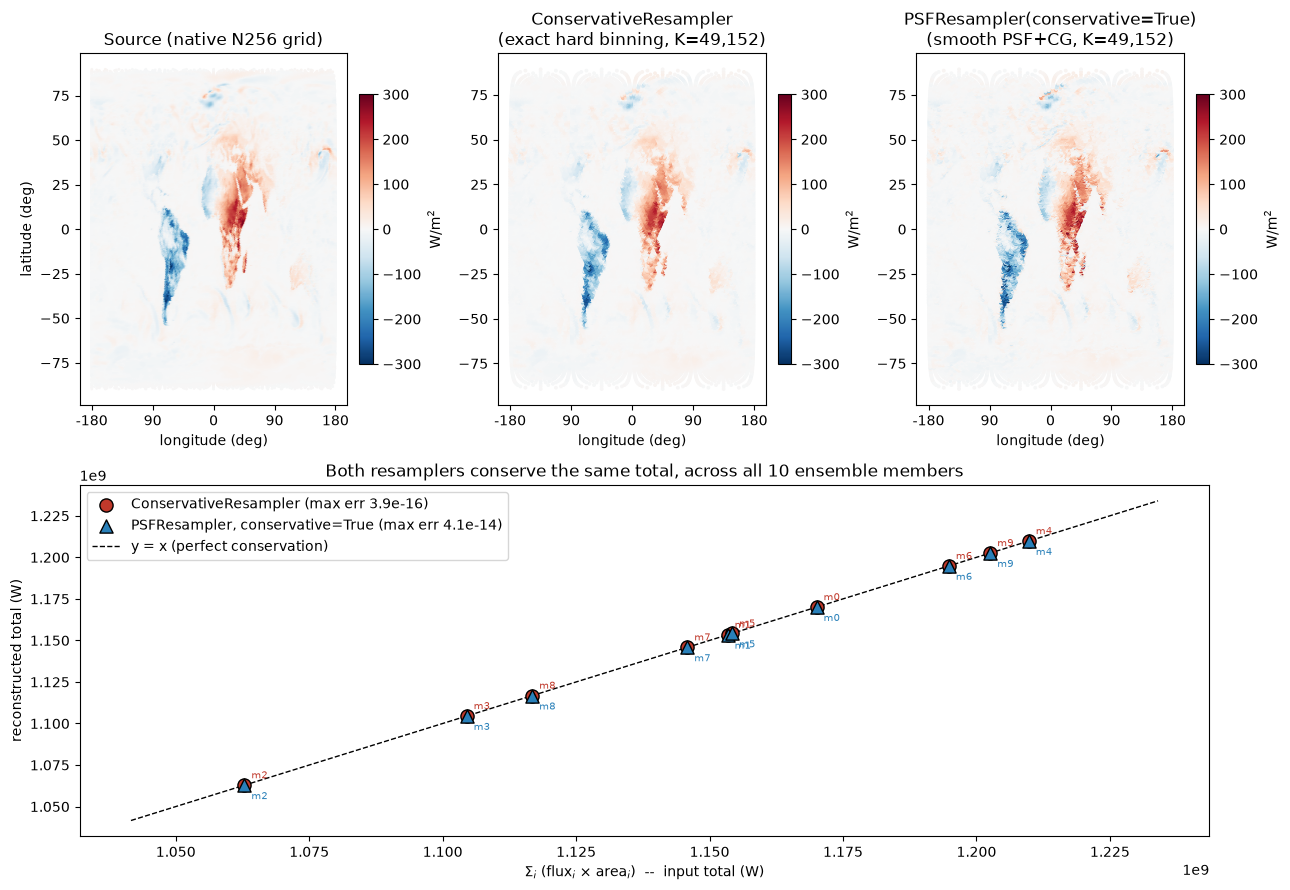

In [19]:
# --- Panel B: ConservativeResampler (Sections 5-7) ---
cell_ids_cons = res.cell_ids if isinstance(res.cell_ids, np.ndarray) else res.cell_ids.cpu().numpy()
hval_cons_np = res.cell_data if isinstance(res.cell_data, np.ndarray) else res.cell_data.cpu().numpy()
lon_cons, lat_cons = healpix_geo.nested.healpix_to_lonlat(cell_ids_cons.astype(np.uint64), level, ellipsoid="WGS84")
density_cons0 = hval_cons_np[0] / op.get_cell_area()

# --- Panel C: PSFResampler(conservative=True) (Section 9, all members) ---
cell_ids_psf = res_psf_all.cell_ids if isinstance(res_psf_all.cell_ids, np.ndarray) else res_psf_all.cell_ids.cpu().numpy()
lon_psf, lat_psf = healpix_geo.nested.healpix_to_lonlat(cell_ids_psf.astype(np.uint64), level, ellipsoid="WGS84")
density_psf0 = hval_psf_all[0]   # already an intensive field value (W/m^2), no division needed

fig = plt.figure(figsize=(13, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, :])

vmin, vmax = -300, 300
sc0 = ax0.scatter((lon+180)%360, lat, c=flux[0], s=1.0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax0.set_title("Source (native N256 grid)")
ax0.set_xticks([0,90,180,270,360],['-180','90','0','90','180'])
fig.colorbar(sc0, ax=ax0, label="W/m$^2$", fraction=0.046, pad=0.04)

sc1 = ax1.scatter((lon_cons+180)%360, lat_cons, c=density_cons0, s=3, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax1.set_title(f"ConservativeResampler\n(exact hard binning, K={op.K:,})")
ax1.set_xticks([0,90,180,270,360],['-180','90','0','90','180'])
fig.colorbar(sc1, ax=ax1, label="W/m$^2$", fraction=0.046, pad=0.04)

sc2 = ax2.scatter((lon_psf+180)%360, lat_psf, c=density_psf0, s=3, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax2.set_title(f"PSFResampler(conservative=True)\n(smooth PSF+CG, K={psf_op.K:,})")
ax2.set_xticks([0,90,180,270,360],['-180','90','0','90','180'])
fig.colorbar(sc2, ax=ax2, label="W/m$^2$", fraction=0.046, pad=0.04)

for ax in (ax0, ax1, ax2):
    ax.set_xlabel("longitude (deg)")
ax0.set_ylabel("latitude (deg)")

members = np.arange(flux.shape[0])
ax3.scatter(flux_in, flux_out, s=90, marker="o", color="#c0392b", edgecolor="k", zorder=3,
            label=f"ConservativeResampler (max err {rel_err_cons.max():.1e})")
ax3.scatter(flux_in, total_psf, s=90, marker="^", color="#2980b9", edgecolor="k", zorder=3,
            label=f"PSFResampler, conservative=True (max err {rel_err_psf.max():.1e})")
lims = [flux_in.min() * 0.98, flux_in.max() * 1.02]
ax3.plot(lims, lims, "k--", lw=1, zorder=1, label="y = x (perfect conservation)")
for b in members:
    ax3.annotate(f"m{b}", (flux_in[b], flux_out[b]), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color="#c0392b")
    ax3.annotate(f"m{b}", (flux_in[b], total_psf[b]), textcoords="offset points",
                 xytext=(5, -10), fontsize=7, color="#2980b9")
ax3.set_xlabel(r"$\Sigma_i$ (flux$_i$ $\times$ area$_i$)  --  input total (W)")
ax3.set_ylabel("reconstructed total (W)")
ax3.set_title("Both resamplers conserve the same total, across all 10 ensemble members")
ax3.legend(loc="upper left")
ax3.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

fig.tight_layout()
fig.savefig('figures/conservative_proof.pdf')

Both markers, for every one of the 10 ensemble members, sit on the same $y=x$ line as the
input total -- `ConservativeResampler` by exact hard-binning bookkeeping, `PSFResampler` by
an explicit, exact Lagrange-multiplier correction on top of a smooth PSF+CG deconvolution.
The visual difference between panels B and C (blocky vs. smooth) is the accuracy/smoothness
trade-off discussed in Section 8 -- it is completely orthogonal to conservation, which both
panels satisfy exactly.


## Conclusion

- The exact area of each N256 reduced-Gaussian-grid point was computed directly from the
  decoded coordinates (exact spherical-zone formula — verified: the sum reproduces `4πR²` to
  1e-16).
- Ignoring that area already biases a plain global mean of the flux, purely from the ~3.6x
  area ratio between the smallest and largest source pixel.
- `ConservativeResampler(..., area=area_km2)` exactly conserves `sum(flux × area)`, in watts,
  on the forward pass (`resample`) and on the way back (`invert`), for all 10 ensemble members
  processed in a single batched call on this real ERA5 **surface sensible heat flux** field —
  verified above to machine precision (Section 6), and shown irrefutably in Section 7: the two
  independently-computed totals agree to the digits printed on the maps, and all 10 ensemble
  members fall exactly on the `y = x` line to within ~1e-15 relative error.
- `PSFResampler(..., area=area_km2).resample(..., conservative=True)` gets the same exact
  mean-matching guarantee out of the library's own constrained CG solve — proved directly on
  the output of that call in Section 9, with no manual notebook-level correction — while still
  producing a smooth, deconvolved field rather than a piecewise-constant one.
- Section 10 puts both resamplers on the same figure and the same `y = x` axes, across all 10
  members: `ConservativeResampler`'s exact bookkeeping and `PSFResampler`'s exact
  Lagrange-multiplier correction land on the same input total, each to machine precision —
  the combined, definitive proof that both conservative code paths in `healpix-resample`
  deliver on the same guarantee, however different their internal mechanics.
- The piecewise-constant, blocky appearance of `ConservativeResampler`'s output is the expected
  signature of *conservative* (binning) resampling, not a conservation defect — it is
  orthogonal to, and independent from, the exact conservation property demonstrated throughout.
